In [1]:
import torch

In [2]:
inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89], # Your
        [0.55, 0.87, 0.66], # journey
        [0.57, 0.85, 0.64], # starts
        [0.22, 0.58, 0.33], # with
        [0.77, 0.25, 0.10], # one
        [0.05, 0.80, 0.55], # step
    ]
)

In [5]:
# computing the attention scores for the 2nd input ("journey")
index = 1
query = inputs[index]
attention_scores = {}
attention_scores[index] = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attention_scores[index][i] = torch.dot(x_i, query)
print(attention_scores[index])

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [6]:
attention_weights_2_tmp = attention_scores[index] / attention_scores[1].sum()
print("Attention weights:", attention_weights_2_tmp)
print("Sum:", attention_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


In [23]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attention_weights_2_naive = softmax_naive(attention_scores[index])
print("Attention weights:", attention_weights_2_naive)
print("Sum:", attention_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [24]:
attention_weights_2 = torch.softmax(attention_scores[index], dim=0)
print("Attention weights:", attention_weights_2)
print("Sum:", attention_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [28]:
print("Attention weights:", attention_weights_2[1])
print("Input:", inputs[1])
print("Multiplied:", attention_weights_2[1] * inputs[1])

Attention weights: tensor(0.2379)
Input: tensor([0.5500, 0.8700, 0.6600])
Multiplied: tensor([0.1308, 0.2070, 0.1570])


In [29]:
context_vec_2 = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vec_2 += attention_weights_2[i] * x_i
    print(i, ":", context_vec_2)

0 : tensor([0.0596, 0.0208, 0.1233])
1 : tensor([0.1904, 0.2277, 0.2803])
2 : tensor([0.3234, 0.4260, 0.4296])
3 : tensor([0.3507, 0.4979, 0.4705])
4 : tensor([0.4340, 0.5250, 0.4813])
5 : tensor([0.4419, 0.6515, 0.5683])


In [31]:
# let's compute the entire set of attention scores with for loops
attention_scores = torch.empty(6, 6)
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attention_scores[i, j] = torch.dot(x_i, x_j)
print(attention_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [36]:
transposed_inputs = inputs.T
attention_scores = inputs.matmul(transposed_inputs) # same as `inputs @ inputs.T`
print(attention_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [37]:
attention_weights = torch.softmax(attention_scores, dim=-1)
print(attention_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [63]:
row_2_sum = sum(attention_weights[1])
print("Row 2 sum:", row_2_sum)
print("Allow row sums:", attention_weights.sum(dim=-1))

Row 2 sum: tensor(1.)
Allow row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [64]:
all_context_vecs = attention_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


In [65]:
# --- misc musings below

In [4]:
torch.empty(inputs.shape[0])

tensor([0., 0., 0., 0., 0., 0.])

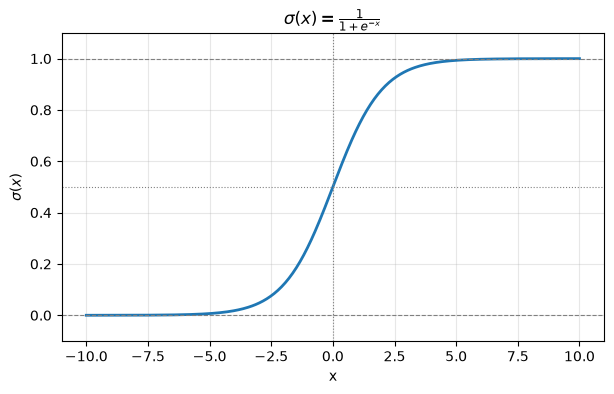

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 400)
y = sigmoid(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, linewidth=2)

# reference lines: the asymptotes and the midpoint
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")

ax.set_title(r"$\sigma(x) = \frac{1}{1 + e^{-x}}$")
ax.set_xlabel("x")
ax.set_ylabel(r"$\sigma(x)$")
ax.set_ylim(-0.1, 1.1)
ax.grid(alpha=0.3)

plt.show()

In [22]:
#def sigmoid(x):
#    return 1 / (1 + np.exp(-x))

# sigmoid = torch.nn.Sigmoid()

print("σ(-99) => ", torch.sigmoid(torch.tensor(-99.0)))
print("σ(99) => ", torch.sigmoid(torch.tensor(99.0)))
print("σ(0.123) => ", torch.sigmoid(torch.tensor(0.123)))
print("σ(-2) => ", torch.sigmoid(torch.tensor(-2.0)))
print("σ(1) => ", torch.sigmoid(torch.tensor(1.0)))

σ(-99) =>  tensor(0.)
σ(99) =>  tensor(1.)
σ(0.123) =>  tensor(0.5307)
σ(-2) =>  tensor(0.1192)
σ(1) =>  tensor(0.7311)
